# Tag 07 — Anfänger
## Your First Decision Tree — Heart Disease

تمرین‌های این نوت‌بوک:
1. آموزش `DecisionTreeClassifier(max_depth=3)` و چاپ Accuracy برای Train/Test
2. رسم درخت و پیدا کردن Root Feature
3. مقایسه معیارهای `gini` و `entropy`

In [1]:
import sys
# !{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Find project root automatically
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output" / "Anfaenger"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Output dir:", OUTPUT_DIR)


Project root: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\decision-trees-predictive-modeling
Data dir: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\decision-trees-predictive-modeling\data
Output dir: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\decision-trees-predictive-modeling\output\Anfaenger


## 1) Load data

In [3]:

heart_path = DATA_DIR / "heart.csv"
if not heart_path.exists():
    raise FileNotFoundError(f"Could not find {heart_path}. Put heart.csv into ../data/.")

df = pd.read_csv(heart_path)
print(df.shape)
df.head()


(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:

print(df.info())
print("\nMissing values:")
print(df.isna().sum())
print("\nTarget distribution:")
print(df["target"].value_counts(normalize=True).round(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
d

## 2) Split X/y and Train/Test

In [5]:

X = df.drop(columns=["target"])
y = df["target"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_tr.shape)
print("X_test :", X_te.shape)
print("Train target ratio:\n", y_tr.value_counts(normalize=True).round(3))
print("Test target ratio:\n", y_te.value_counts(normalize=True).round(3))


X_train: (242, 13)
X_test : (61, 13)
Train target ratio:
 target
1    0.545
0    0.455
Name: proportion, dtype: float64
Test target ratio:
 target
1    0.541
0    0.459
Name: proportion, dtype: float64


## 3) Task 1 — Train Decision Tree max_depth=3

In [6]:

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_tr, y_tr)

train_acc = dt.score(X_tr, y_tr)
test_acc = dt.score(X_te, y_te)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

pd.DataFrame({"metric": ["train_accuracy", "test_accuracy"], "value": [train_acc, test_acc]}).to_csv(
    OUTPUT_DIR / "beginner_accuracy.csv", index=False
)


Train Accuracy: 0.8471
Test Accuracy : 0.7541


              precision    recall  f1-score   support

  No disease       0.76      0.68      0.72        28
     Disease       0.75      0.82      0.78        33

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



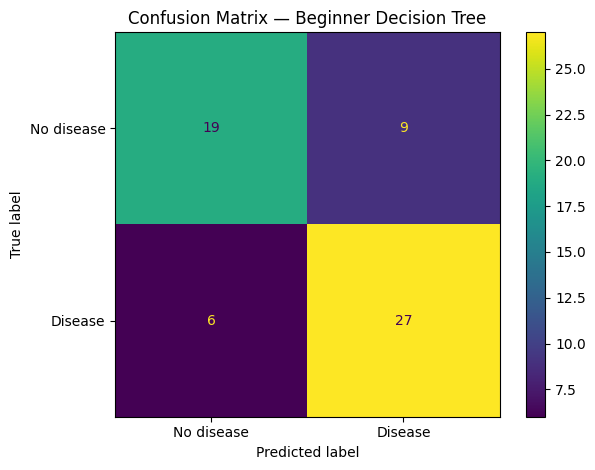

In [7]:

y_pred = dt.predict(X_te)
print(classification_report(y_te, y_pred, target_names=["No disease", "Disease"]))

cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No disease", "Disease"])
disp.plot()
plt.title("Confusion Matrix — Beginner Decision Tree")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_confusion_matrix.png", dpi=150)
plt.show()


## 4) Task 2 — Visualise the Tree and Root Feature

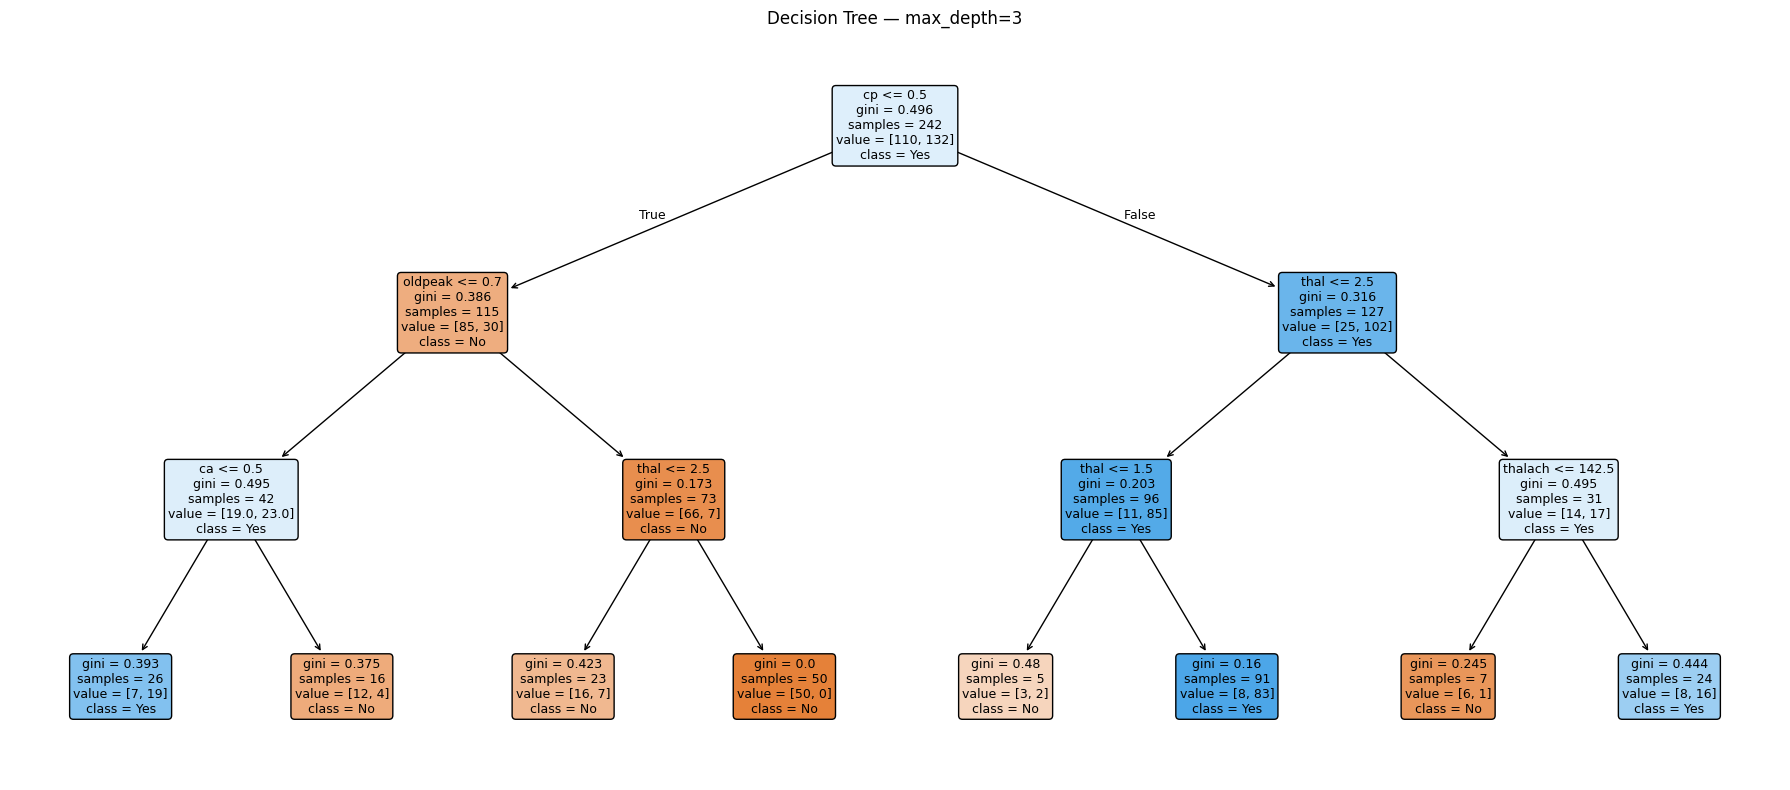

Root feature: cp

Text version of the tree:

|--- cp <= 0.50
|   |--- oldpeak <= 0.70
|   |   |--- ca <= 0.50
|   |   |   |--- class: 1
|   |   |--- ca >  0.50
|   |   |   |--- class: 0
|   |--- oldpeak >  0.70
|   |   |--- thal <= 2.50
|   |   |   |--- class: 0
|   |   |--- thal >  2.50
|   |   |   |--- class: 0
|--- cp >  0.50
|   |--- thal <= 2.50
|   |   |--- thal <= 1.50
|   |   |   |--- class: 0
|   |   |--- thal >  1.50
|   |   |   |--- class: 1
|   |--- thal >  2.50
|   |   |--- thalach <= 142.50
|   |   |   |--- class: 0
|   |   |--- thalach >  142.50
|   |   |   |--- class: 1



In [8]:

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
plt.title("Decision Tree — max_depth=3")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_decision_tree.png", dpi=150)
plt.show()

root_feature_index = dt.tree_.feature[0]
root_feature = X.columns[root_feature_index]
print("Root feature:", root_feature)

print("\nText version of the tree:\n")
print(export_text(dt, feature_names=list(X.columns)))


## 5) Task 3 — Compare Gini vs Entropy

In [9]:

results = []
models = {}
for criterion in ["gini", "entropy"]:
    model = DecisionTreeClassifier(max_depth=3, criterion=criterion, random_state=42)
    model.fit(X_tr, y_tr)
    train_acc = model.score(X_tr, y_tr)
    test_acc = model.score(X_te, y_te)
    root = X.columns[model.tree_.feature[0]]
    results.append({
        "criterion": criterion,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "root_feature": root,
        "node_count": model.tree_.node_count,
        "max_depth": model.tree_.max_depth
    })
    models[criterion] = model

results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_DIR / "beginner_gini_vs_entropy.csv", index=False)
results_df


,criterion,train_accuracy,test_accuracy,root_feature,node_count,max_depth
0,gini,0.847107,0.754098,cp,15,3
1,entropy,0.838843,0.786885,cp,15,3


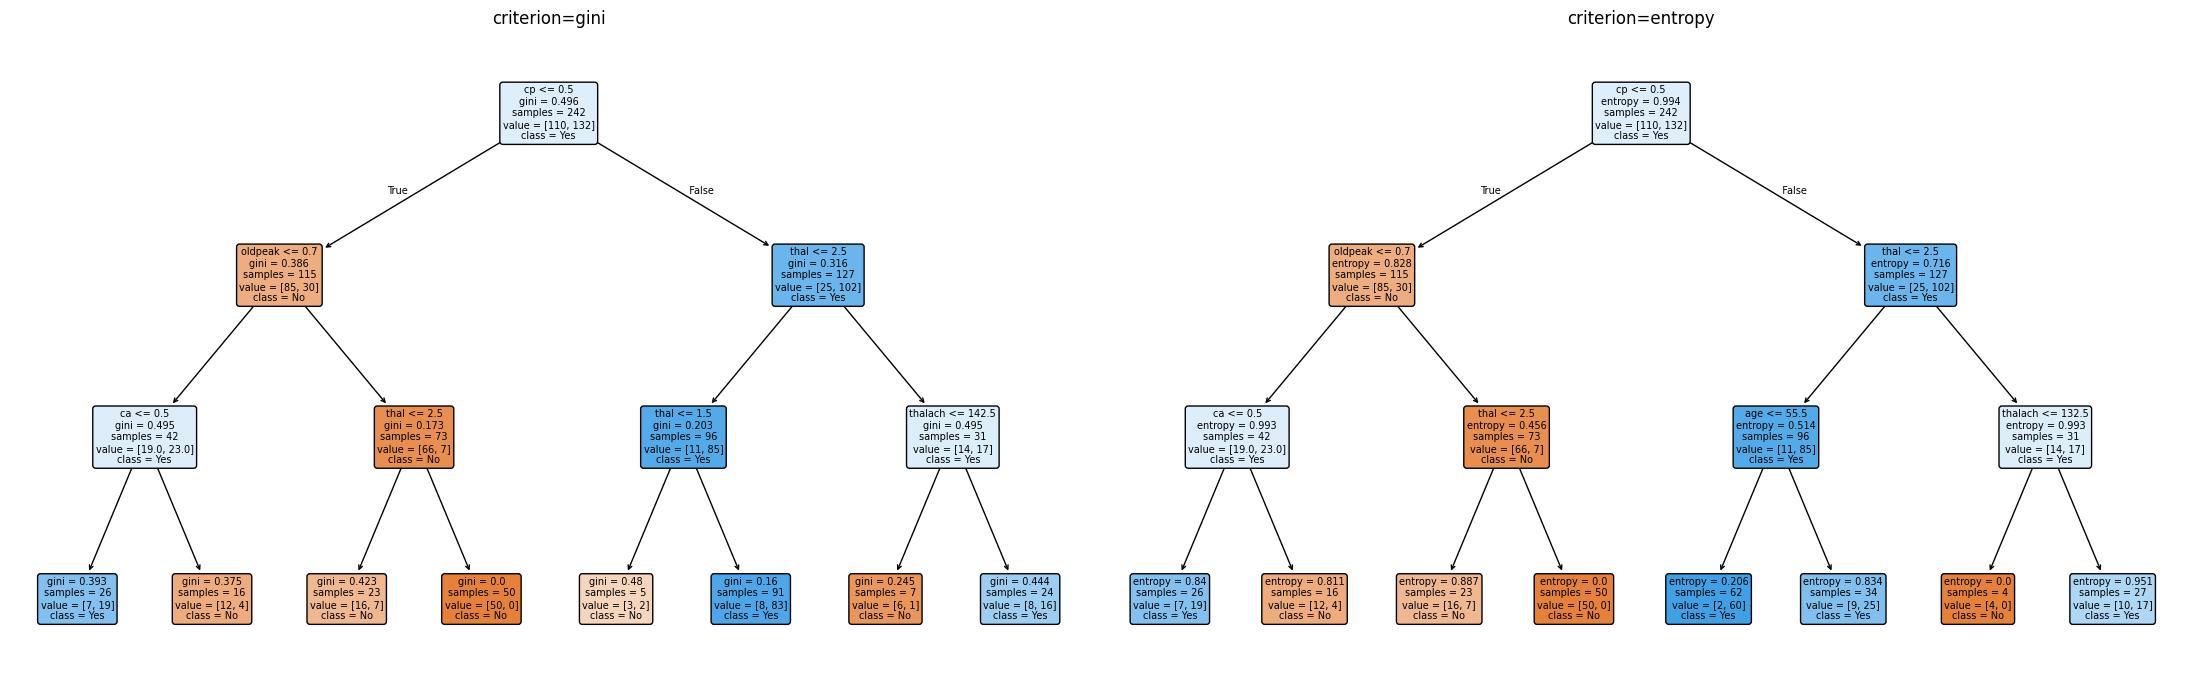

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
for ax, criterion in zip(axes, ["gini", "entropy"]):
    plot_tree(
        models[criterion],
        feature_names=X.columns.tolist(),
        class_names=["No", "Yes"],
        filled=True,
        rounded=True,
        fontsize=7,
        ax=ax
    )
    ax.set_title(f"criterion={criterion}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_gini_vs_entropy_trees.png", dpi=150)
plt.show()


## 6) What to send back to ChatGPT

بعد از اجرا، این فایل‌ها/اسکرین‌شات‌ها را بده تا تحلیل کنم:

- `output/Anfaenger/beginner_accuracy.csv`
- `output/Anfaenger/beginner_gini_vs_entropy.csv`
- عکس درخت یا خروجی `Root feature`
- خروجی `classification_report`